--- Downloading NLTK Core Components ---
--- Ingesting Email Spam Records from: /kaggle/input/datasets/purusinghvi/email-spam-classification-dataset/combined_data.csv ---


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Dataset Shape: (83448, 2) rows processed.
label
1    0.526196
0    0.473804
Name: proportion, dtype: float64


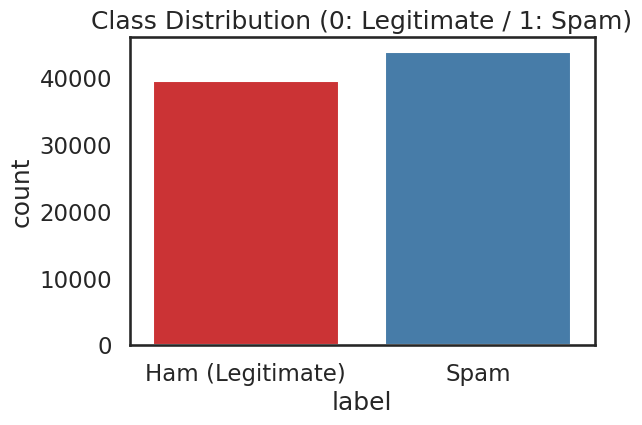

--- Initializing Text Sanitization Layer (Tokenization & Lemmatization) ---
Executing cleaning transformations over text blocks... (This may take a minute)
Vocabulary Vector Dimensions: (66758, 5000)
Training Multinomial Naive Bayes Engine...
Training Logistic Regression Engine...

MULTINOMIAL NAIVE BAYES PERFORMANCE
Accuracy: 0.9672
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      7908
           1       0.97      0.97      0.97      8782

    accuracy                           0.97     16690
   macro avg       0.97      0.97      0.97     16690
weighted avg       0.97      0.97      0.97     16690

LOGISTIC REGRESSION PERFORMANCE
Accuracy: 0.9829
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      7908
           1       0.98      0.99      0.98      8782

    accuracy                           0.98     16690
   macro avg       0.98      0.98      0.98     16690
weighted avg    

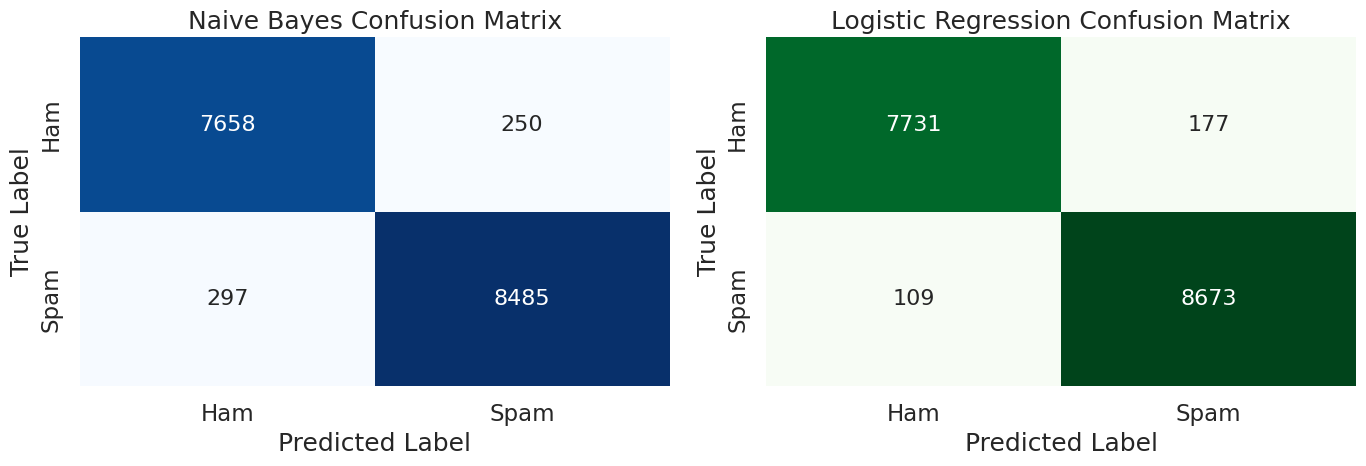

In [3]:
# ==============================================================================
# 1. ENVIRONMENT CONFIGURATION & LIBRARIES (FIXED)
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import os
import warnings
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

warnings.filterwarnings('ignore')

# Download required NLTK core packages
print("--- Downloading NLTK Core Components ---")
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Set portfolio visualization aesthetics
sns.set_theme(style="white", context="talk")
plt.rcParams['figure.figsize'] = (18, 6)

# Explicit Kaggle data path from user input
DATA_PATH = '/kaggle/input/datasets/purusinghvi/email-spam-classification-dataset/combined_data.csv' 
if not os.path.exists(DATA_PATH):
    for root, dirs, files in os.walk('/kaggle/input/'):
        for file in files:
            if file.endswith('.csv'):
                DATA_PATH = os.path.join(root, file)
                break

# ==============================================================================
# 2. DATA INGESTION & EXPLORATORY ANALYSIS
# ==============================================================================
print(f"--- Ingesting Email Spam Records from: {DATA_PATH} ---")
df = pd.read_csv(DATA_PATH)

# Drop missing records to maintain absolute data safety
df.dropna(subset=['text', 'label'], inplace=True)

print(f"Dataset Shape: {df.shape} rows processed.")
print(df['label'].value_counts(normalize=True)) # Imbalance verification

# Plot Class Balance Distribution Count
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df, palette='Set1')
plt.title('Class Distribution (0: Legitimate / 1: Spam)')
plt.xticks([0, 1], ['Ham (Legitimate)', 'Spam'])
plt.show()

# ==============================================================================
# 3. ADVANCED TEXT PREPROCESSING ENGINE (NLP)
# ==============================================================================
print("--- Initializing Text Sanitization Layer (Tokenization & Lemmatization) ---")
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_email_text(text):
    # 1. Convert to lowercase
    text = str(text).lower()
    # 2. Remove email subjects headers tags, URLs and HTML markers
    text = re.sub(r'subject:', '', text)
    text = re.sub(r'http\S+|www\S+|<.*?>', '', text)
    # 3. Strip special punctuation configurations & numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # 4. Tokenize, remove stopwords, and apply Lemmatization
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    return " ".join(cleaned_words)

# Apply Text Ingestion Engine on the dataframe
print("Executing cleaning transformations over text blocks... (This may take a minute)")
df['cleaned_text'] = df['text'].apply(clean_email_text)

# ==============================================================================
# 4. MATRIX VECTORIZATION & SPLITTING (TF-IDF)
# ==============================================================================
# Feature space isolation
X = df['cleaned_text']
y = df['label'].astype(int)

# 80/20 train-test ratio splitting with stratification to keep class balances intact
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Instantiate high-performance TF-IDF vector configuration constraints
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"Vocabulary Vector Dimensions: {X_train_vec.shape}")

# ==============================================================================
# 5. ML ENGINE TRAINING & MODEL COMPARISONS
# ==============================================================================
# Initializing Classifiers
nb_classifier = MultinomialNB(alpha=0.1)
lr_classifier = LogisticRegression(max_iter=500, solver='liblinear', random_state=42)

print("Training Multinomial Naive Bayes Engine...")
nb_classifier.fit(X_train_vec, y_train)

print("Training Logistic Regression Engine...")
lr_classifier.fit(X_train_vec, y_train)

# Calculate Inference Arrays
nb_preds = nb_classifier.predict(X_test_vec)
lr_preds = lr_classifier.predict(X_test_vec)

# ==============================================================================
# 6. PORTFOLIO EVALUATION REPORTING
# ==============================================================================
print("\n" + "="*50)
print("MULTINOMIAL NAIVE BAYES PERFORMANCE")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, nb_preds):.4f}")
print(classification_report(y_test, nb_preds))

print("="*50)
print("LOGISTIC REGRESSION PERFORMANCE")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.4f}")
print(classification_report(y_test, lr_preds))

# ==============================================================================
# 7. COMPARATIVE CONFUSION MATRIX VISUALIZATION (FINAL FIXED INDEXING)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Naive Bayes Matrix Mapping -> Left Plot (axes[0])
cm_nb = confusion_matrix(y_test, nb_preds)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0], annot_kws={"size": 16})
axes[0].set_title('Naive Bayes Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticklabels(['Ham', 'Spam'])
axes[0].set_yticklabels(['Ham', 'Spam'])

# Plot B: Logistic Regression Matrix Mapping -> Right Plot (axes[1])
cm_lr = confusion_matrix(y_test, lr_preds)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[1], annot_kws={"size": 16})
axes[1].set_title('Logistic Regression Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].set_xticklabels(['Ham', 'Spam'])
axes[1].set_yticklabels(['Ham', 'Spam'])

plt.tight_layout()
plt.show()